In [2]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "duckdb", "pandas", "numpy"])

import os
import duckdb

con = duckdb.connect()        

print("Files in Data/:", os.listdir("Data"))

Files in Data/: ['data_jobs.csv']


In [4]:
con.sql("select * from 'Data/data_jobs.csv' limit 5").df()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [9]:
con.sql("""SELECT
    count(*)                  AS total_rows,
    count(job_title_short)    AS has_role,
    count(job_skills)         AS has_skills,
    count(salary_year_avg)    AS has_salary_year,
    count(salary_hour_avg)    AS has_salary_hour,
    count(salary_rate) AS salary_rate,	
    count(salary_year_avg)	AS salary_year_avg,
    count(salary_hour_avg) AS	salary_hours_avg,
    count(job_country)        AS has_country,
    count(job_posted_date)    AS has_date,
    count(company_name)       AS has_company
FROM 'Data/data_jobs.csv'""").df()

,total_rows,has_role,has_skills,has_salary_year,has_salary_hour,salary_rate,salary_year_avg,salary_hours_avg,has_country,has_date,has_company
0,785741,785741,668704,22003,10662,33067,22003,10662,785692,785741,785740


In [10]:
FILE = "Data/data_jobs.csv"

In [11]:
con.sql(f"""
SELECT
    count(DISTINCT job_title_short)   AS n_roles,
    count(DISTINCT job_country)       AS n_countries,
    count(DISTINCT job_schedule_type) AS n_schedules,
    count(DISTINCT salary_rate)       AS n_salary_rates,
    count(DISTINCT company_name)      AS n_companies
FROM '{FILE}'
""").df()

,n_roles,n_countries,n_schedules,n_salary_rates,n_companies
0,10,160,47,5,139984


In [14]:
con.sql(f"""
SELECT job_country, count(*) AS postings
FROM '{FILE}'
GROUP BY job_country
ORDER BY postings DESC
LIMIT 30
""").df()

,job_country,postings
0,United States,206292
1,India,51088
2,United Kingdom,40375
3,France,39922
4,Germany,27694
5,Spain,25100
6,Singapore,23696
7,Sudan,21781
8,Netherlands,20631
9,Italy,17013


In [15]:
con.sql(f"""
SELECT job_schedule_type, count(*) AS postings
FROM '{FILE}'
GROUP BY job_schedule_type
ORDER BY postings DESC
LIMIT 25
""").df()

,job_schedule_type,postings
0,Full-time,701727
1,Contractor,34793
2,NaN,12667
3,Internship,8742
4,Part-time,7881
5,Full-time and Part-time,6287
6,Full-time and Temp work,2603
7,Full-time and Internship,2340
8,Full-time and Contractor,2292
9,Contractor and Temp work,2283


In [18]:
con.sql(f"""
SELECT
    job_country,
    count(*)                                                      AS all_postings,
    round(100.0 * count(*) / sum(count(*)) OVER (), 2)            AS percentage_of_all,
    count(salary_year_avg)                                        AS salaried,
    round(100.0 * count(salary_year_avg)
          / sum(count(salary_year_avg)) OVER (), 2)               AS percentage_of_salaried
FROM '{FILE}'
GROUP BY job_country
ORDER BY salaried DESC
LIMIT 15
""").df()

,job_country,all_postings,percentage_of_all,salaried,percentage_of_salaried
0,United States,206292,26.25,15766,71.65
1,Sudan,21781,2.77,1623,7.38
2,India,51088,6.50,582,2.65
3,Canada,16029,2.04,463,2.10
4,United Kingdom,40375,5.14,287,1.30
5,Germany,27694,3.52,257,1.17
6,France,39922,5.08,237,1.08
7,Poland,14793,1.88,200,0.91
8,Spain,25100,3.19,144,0.65
9,Portugal,14508,1.85,131,0.60


In [19]:
con.sql(f"""
SELECT job_location, search_location, job_via, count(*) AS postings
FROM '{FILE}'
WHERE job_country = 'Sudan'
GROUP BY 1,2,3
ORDER BY postings DESC
LIMIT 20
""").df()

,job_location,search_location,job_via,postings
0,Anywhere,Sudan,via LinkedIn,2514
1,United States,Sudan,via BeBee,805
2,United States,Sudan,via Trabajo.org,590
3,Anywhere,Sudan,via Upwork,431
4,United States,Sudan,via LinkedIn,327
5,"Albuquerque, NM",Sudan,via Trabajo.org,279
6,Anywhere,Sudan,via Indeed,237
7,"Santa Fe, NM",Sudan,via BeBee,230
8,Anywhere,Sudan,via ZipRecruiter,193
9,"Houston, TX",Sudan,via LinkedIn,176


In [20]:
con.sql(f"""
SELECT
    job_country,
    count(*)                                                   AS postings,
    sum(CASE WHEN job_location = 'Anywhere' THEN 1 ELSE 0 END) AS anywhere_rows,
    round(100.0 * sum(CASE WHEN job_location = 'Anywhere' THEN 1 ELSE 0 END)
          / count(*), 1)                                       AS pct_anywhere
FROM '{FILE}'
GROUP BY job_country
ORDER BY postings DESC
LIMIT 20
""").df()

,job_country,postings,anywhere_rows,pct_anywhere
0,United States,206292,23021.0,11.2
1,India,51088,5712.0,11.2
2,United Kingdom,40375,3764.0,9.3
3,France,39922,1694.0,4.2
4,Germany,27694,1328.0,4.8
5,Spain,25100,2645.0,10.5
6,Singapore,23696,266.0,1.1
7,Sudan,21781,3930.0,18.0
8,Netherlands,20631,740.0,3.6
9,Italy,17013,738.0,4.3


In [21]:
con.sql(f"""
SELECT
    job_country,
    count(*)                                        AS postings,
    sum(CASE WHEN job_location LIKE '%, AL' OR job_location LIKE '%, AK'
              OR job_location LIKE '%, AZ' OR job_location LIKE '%, CA'
              OR job_location LIKE '%, CO' OR job_location LIKE '%, FL'
              OR job_location LIKE '%, GA' OR job_location LIKE '%, IL'
              OR job_location LIKE '%, MA' OR job_location LIKE '%, NM'
              OR job_location LIKE '%, NY' OR job_location LIKE '%, TX'
              OR job_location LIKE '%, VA' OR job_location LIKE '%, WA'
              OR job_location = 'United States'
         THEN 1 ELSE 0 END)                         AS us_looking,
    round(100.0 * sum(CASE WHEN job_location LIKE '%, TX'
              OR job_location LIKE '%, NM' OR job_location LIKE '%, NY'
              OR job_location LIKE '%, CA' OR job_location = 'United States'
         THEN 1 ELSE 0 END) / count(*), 1)          AS pct_us_sample
FROM '{FILE}'
WHERE job_country <> 'United States'
GROUP BY job_country
ORDER BY postings DESC
LIMIT 20
""").df()

,job_country,postings,us_looking,pct_us_sample
0,India,51088,0.0,0.0
1,United Kingdom,40375,0.0,0.0
2,France,39922,0.0,0.0
3,Germany,27694,0.0,0.0
4,Spain,25100,0.0,0.0
5,Singapore,23696,0.0,0.0
6,Sudan,21781,13655.0,47.3
7,Netherlands,20631,0.0,0.0
8,Italy,17013,0.0,0.0
9,Canada,16029,0.0,0.0


In [22]:
con.sql(f"""
SELECT job_location, count(*) AS postings
FROM '{FILE}'
WHERE job_country = 'Sudan'
  AND job_location <> 'Anywhere'
  AND job_location NOT LIKE '%, %'
  AND job_location <> 'United States'
GROUP BY job_location
ORDER BY postings DESC
LIMIT 25
""").df()


,job_location,postings
0,Texas,569
1,Colorado,29
2,New Mexico,28
3,New Jersey,19
4,California,16
5,Virginia,16
6,Arizona,16
7,Nebraska,12
8,Pennsylvania,12
9,Ohio,10


In [3]:
import duckdb
con = duckdb.connect()
FILE = "Data/data_jobs.csv"

US_STATES = ('Texas','Colorado','New Mexico','New Jersey','California','Virginia',
 'Arizona','Nebraska','Pennsylvania','Ohio','Arkansas','Utah','Massachusetts',
 'Florida','Illinois','Michigan','North Carolina','Kansas','Maryland','Oklahoma',
 'New York','Connecticut','Georgia','Washington','Oregon','Nevada','Minnesota',
 'Wisconsin','Indiana','Missouri','Tennessee','Alabama','Louisiana','Kentucky',
 'South Carolina','Iowa','Mississippi','Idaho','Montana','Wyoming','Maine',
 'New Hampshire','Vermont','Rhode Island','Delaware','West Virginia','Alaska',
 'Hawaii','North Dakota','South Dakota')

con.execute(f"""
CREATE OR REPLACE TABLE jobs AS
SELECT
    *,
    CASE
      WHEN job_country <> 'Sudan' THEN job_country
      WHEN job_location = 'Anywhere' THEN 'Remote'
      WHEN regexp_matches(job_location, ', [A-Z]{{2}}$')
           OR job_location LIKE 'United States%'
           OR job_location IN {US_STATES}          THEN 'United States'
      ELSE NULL
    END AS country_clean
FROM '{FILE}'
""")

con.sql("""
SELECT country_clean,
       count(*) AS rows,
       count(salary_year_avg) AS salaried
FROM jobs
WHERE job_country = 'Sudan'
GROUP BY 1 ORDER BY rows DESC
""").df()

,country_clean,rows,salaried
0,United States,17759,1179
1,Remote,3930,431
2,NaN,92,13


In [4]:
con.execute("""
CREATE OR REPLACE TABLE job_skills_long AS
SELECT
    job_title_short,
    country_clean,
    job_posted_date,
    job_work_from_home,
    job_no_degree_mention,
    salary_year_avg,
    unnest(
      list_transform(
        list_filter(
          str_split(regexp_replace(job_skills, '^\\[|\\]$', '', 'g'), ','),
          x -> length(trim(x)) > 2),
        x -> lower(trim(trim(trim(x), ''''), '"'))
      )
    ) AS skill
FROM jobs
WHERE job_skills IS NOT NULL
""")

con.sql("""
SELECT count(*) AS skill_rows,
       count(DISTINCT skill) AS distinct_skills
FROM job_skills_long
""").df()

,skill_rows,distinct_skills
0,3660283,252


In [5]:
con.sql("""
SELECT skill, count(*) AS postings
FROM job_skills_long
GROUP BY skill ORDER BY postings DESC LIMIT 20
""").df()

,skill,postings
0,sql,384849
1,python,380909
2,aws,145381
3,azure,132527
4,r,130892
5,tableau,127213
6,excel,127018
7,spark,114609
8,power bi,98147
9,java,85612


In [6]:
con.sql("""
SELECT skill, count(*) AS postings
FROM job_skills_long
GROUP BY skill
ORDER BY postings ASC
LIMIT 20
""").df()

,skill,postings
0,rocketchat,1
1,gtx,1
2,dingtalk,1
3,rubyon rails,1
4,wimi,1
5,msaccess,1
6,visualbasic,1
7,deno,2
8,esquisse,3
9,asp.netcore,3


## Q1 - What skills does each data role actually require?

One global skill ranking tells you nothing - SQL tops every list. The useful cut
is per role: of all Data Analyst postings, what share ask for SQL? For Data
Engineer? For Data Scientist?

**Scope:** 668,704 of 785,741 postings list skills (85.1%). The rest are excluded,
not imputed.

**Decision:** the learning order for the role you're targeting.


In [9]:
con.execute("""
CREATE OR REPLACE TABLE role_totals AS
SELECT job_title_short AS role, count(DISTINCT posting_id) AS role_postings
FROM (SELECT *, row_number() OVER () AS posting_id FROM jobs WHERE job_skills IS NOT NULL)
GROUP BY 1
""")

con.sql("SELECT * FROM role_totals ORDER BY role_postings DESC").df()

,role,role_postings
0,Data Engineer,169362
1,Data Analyst,159394
2,Data Scientist,145807
3,Senior Data Engineer,41632
4,Software Engineer,37668
5,Business Analyst,36755
6,Senior Data Scientist,32076
7,Senior Data Analyst,24870
8,Machine Learning Engineer,12171
9,Cloud Engineer,8969


In [14]:
con.execute("""
CREATE OR REPLACE TABLE skill_pct AS
WITH counted AS (
  SELECT job_title_short AS role, skill, count(*) AS postings
  FROM job_skills_long
  GROUP BY 1, 2
)
SELECT
    c.role,
    c.skill,
    c.postings,
    t.role_postings,
    round(100.0 * c.postings / t.role_postings, 1) AS pct
FROM counted c
JOIN role_totals t ON c.role = t.role
""")

con.sql("""
SELECT role, skill, postings, pct
FROM skill_pct
WHERE role = 'Data Analyst'
ORDER BY pct DESC
LIMIT 20
""").df()

,role,skill,postings,pct
0,Data Analyst,sql,92428,58.0
1,Data Analyst,excel,66860,41.9
2,Data Analyst,python,57190,35.9
3,Data Analyst,tableau,46455,29.1
4,Data Analyst,power bi,39380,24.7
5,Data Analyst,r,29996,18.8
6,Data Analyst,sas,27998,17.6
7,Data Analyst,powerpoint,13822,8.7
8,Data Analyst,word,13562,8.5
9,Data Analyst,sap,11280,7.1


In [15]:
con.sql("""
SELECT
    skill,
    max(CASE WHEN role = 'Data Analyst'   THEN pct END) AS analyst,
    max(CASE WHEN role = 'Data Engineer'  THEN pct END) AS engineer,
    max(CASE WHEN role = 'Data Scientist' THEN pct END) AS scientist
FROM skill_pct
WHERE role IN ('Data Analyst','Data Engineer','Data Scientist')
GROUP BY skill
HAVING max(CASE WHEN role = 'Data Analyst'   THEN pct END) >= 5
    OR max(CASE WHEN role = 'Data Engineer'  THEN pct END) >= 5
    OR max(CASE WHEN role = 'Data Scientist' THEN pct END) >= 5
ORDER BY coalesce(analyst,0) + coalesce(engineer,0) + coalesce(scientist,0) DESC
""").df()

,skill,analyst,engineer,scientist
0,sql,58.0,66.8,54.2
1,python,35.9,63.8,78.0
2,r,18.8,7.5,40.9
3,tableau,29.1,11.1,20.2
4,aws,5.7,36.6,18.0
5,excel,41.9,5.0,12.0
6,azure,6.8,35.8,14.9
7,spark,3.2,31.7,16.7
8,power bi,24.7,11.1,10.8
9,sas,17.6,4.4,20.3


In [16]:
con.execute("""
CREATE OR REPLACE TABLE us_salaried AS
SELECT *, row_number() OVER () AS posting_id
FROM jobs
WHERE country_clean = 'United States'
  AND salary_year_avg IS NOT NULL
  AND job_skills IS NOT NULL
""")

con.sql("SELECT count(*) AS postings, round(median(salary_year_avg)) AS median_usd FROM us_salaried").df()

,postings,median_usd
0,15448,120000.0


In [17]:
con.execute("""
CREATE OR REPLACE TABLE us_skills AS
SELECT
    posting_id, job_title_short AS role, salary_year_avg AS salary,
    unnest(
      list_transform(
        list_filter(str_split(regexp_replace(job_skills,'^\\[|\\]$','','g'), ','),
                    x -> length(trim(x)) > 2),
        x -> lower(trim(trim(trim(x), ''''), '"')))
    ) AS skill
FROM us_salaried
""")

con.sql("""
SELECT skill, count(*) AS postings, round(median(salary)) AS median_usd
FROM us_skills
GROUP BY skill
HAVING count(*) >= 100
ORDER BY median_usd DESC
LIMIT 25
""").df()

,skill,postings,median_usd
0,mongo,221,173500.0
1,cassandra,421,160000.0
2,scala,1428,150000.0
3,tensorflow,870,150000.0
4,kafka,1137,150000.0
5,pytorch,763,150000.0
6,neo4j,101,147500.0
7,airflow,991,147500.0
8,shell,593,147000.0
9,dynamodb,167,145000.0


In [18]:
con.execute("""
CREATE OR REPLACE TABLE pair_base AS
SELECT
    posting_id,
    any_value(role) AS role,
    any_value(salary) AS salary,
    max(CASE WHEN skill = 'sql'    THEN 1 ELSE 0 END) AS has_sql,
    max(CASE WHEN skill = 'python' THEN 1 ELSE 0 END) AS has_python,
    max(CASE WHEN skill = 'spark'  THEN 1 ELSE 0 END) AS has_spark,
    max(CASE WHEN skill = 'aws'    THEN 1 ELSE 0 END) AS has_aws,
    max(CASE WHEN skill = 'tableau' THEN 1 ELSE 0 END) AS has_tableau,
    max(CASE WHEN skill = 'excel'  THEN 1 ELSE 0 END) AS has_excel
FROM us_skills
GROUP BY posting_id
""")

con.sql("""
SELECT
    CASE WHEN has_sql=1 AND has_spark=1 THEN 'both'
         WHEN has_sql=1 THEN 'sql only'
         WHEN has_spark=1 THEN 'spark only'
         ELSE 'neither' END AS grp,
    count(*) AS postings,
    round(median(salary)) AS median_usd
FROM pair_base
GROUP BY 1 ORDER BY median_usd DESC
""").df()

,grp,postings,median_usd
0,spark only,774,145000.0
1,both,2075,140000.0
2,neither,4412,115000.0
3,sql only,8187,115000.0


In [19]:
con.sql("""
SELECT
    role,
    CASE WHEN has_sql=1 AND has_spark=1 THEN 'both'
         WHEN has_spark=1 THEN 'spark only'
         WHEN has_sql=1 THEN 'sql only'
         ELSE 'neither' END AS grp,
    count(*) AS postings,
    round(median(salary)) AS median_usd
FROM pair_base
WHERE role IN ('Data Analyst','Data Engineer','Data Scientist')
GROUP BY 1,2
HAVING count(*) >= 50
ORDER BY role, median_usd DESC
""").df()

,role,grp,postings,median_usd
0,Data Analyst,both,79,110000.0
1,Data Analyst,sql only,2474,90000.0
2,Data Analyst,neither,1388,84825.0
3,Data Engineer,spark only,262,140000.0
4,Data Engineer,both,835,135000.0
5,Data Engineer,neither,558,129100.0
6,Data Engineer,sql only,1551,122500.0
7,Data Scientist,both,533,136500.0
8,Data Scientist,sql only,2114,132245.0
9,Data Scientist,neither,1490,125000.0


In [20]:
con.sql("""
SELECT
    role,
    CASE WHEN has_aws=1 AND has_python=1 THEN 'both'
         WHEN has_aws=1 THEN 'aws only'
         WHEN has_python=1 THEN 'python only'
         ELSE 'neither' END AS grp,
    count(*) AS postings,
    round(median(salary)) AS median_usd
FROM pair_base
WHERE role IN ('Data Analyst','Data Engineer','Data Scientist')
GROUP BY 1,2
HAVING count(*) >= 50
ORDER BY role, median_usd DESC
""").df()

,role,grp,postings,median_usd
0,Data Analyst,aws only,86,110000.0
1,Data Analyst,both,132,100000.0
2,Data Analyst,python only,1325,97087.0
3,Data Analyst,neither,2418,85000.0
4,Data Engineer,both,1207,133000.0
5,Data Engineer,aws only,284,130000.0
6,Data Engineer,python only,1069,125000.0
7,Data Engineer,neither,646,122500.0
8,Data Scientist,aws only,98,145250.0
9,Data Scientist,both,748,132150.0


In [21]:
con.sql("""
SELECT
    regexp_replace(job_title_short, '^Senior ', '') AS role_family,
    CASE WHEN job_title_short LIKE 'Senior %' THEN 'senior' ELSE 'non-senior' END AS level,
    CASE WHEN job_no_degree_mention THEN 'no degree mentioned' ELSE 'degree mentioned' END AS degree,
    count(*) AS postings,
    round(median(salary_year_avg)) AS median_usd
FROM us_salaried
WHERE regexp_replace(job_title_short, '^Senior ', '')
      IN ('Data Analyst','Data Engineer','Data Scientist')
GROUP BY 1,2,3
HAVING count(*) >= 50
ORDER BY role_family, level, degree
""").df()

,role_family,level,degree,postings,median_usd
0,Data Analyst,non-senior,degree mentioned,3124,90000.0
1,Data Analyst,non-senior,no degree mentioned,837,90000.0
2,Data Analyst,senior,degree mentioned,700,110000.0
3,Data Analyst,senior,no degree mentioned,140,116250.0
4,Data Engineer,non-senior,degree mentioned,2445,125000.0
5,Data Engineer,non-senior,no degree mentioned,761,125000.0
6,Data Engineer,senior,degree mentioned,925,150000.0
7,Data Engineer,senior,no degree mentioned,234,150000.0
8,Data Scientist,non-senior,degree mentioned,4324,129991.0
9,Data Scientist,non-senior,no degree mentioned,55,120000.0


## Q1. What skills does each data role actually require?

**Answer.** Each role has a distinct signature. A single global ranking hides it.

| skill | Analyst | Engineer | Scientist |
|---|---|---|---|
| sql | 58.0 | 66.8 | 54.2 |
| python | 35.9 | 63.8 | 78.0 |
| excel | 41.9 | 5.0 | 12.0 |
| tableau | 29.1 | 11.1 | 20.2 |
| power bi | 24.7 | 11.1 | 10.8 |
| r | 18.8 | 7.5 | 40.9 |
| aws | 5.7 | 36.6 | 18.0 |
| azure | 6.8 | 35.8 | 14.9 |
| spark | 3.2 | 31.7 | 16.7 |
| tensorflow | 0.5 | 1.4 | 13.1 |

Percent of that role's skill-listing postings, 2023.

* **SQL is the floor, not a differentiator.** 54 to 67 percent in every role.
* **Python tracks the role gradient.** 36, then 64, then 78 percent.
* **Excel is the sharpest divide.** 41.9 percent analyst against 5.0 percent engineer.
* **Role signatures.** Analyst is BI tools and spreadsheets. Engineer is cloud and pipelines: AWS, Azure, Spark, Kafka at 17.2, Airflow at 15.1. Scientist is stats and ML: R, TensorFlow, PyTorch at 10.3, scikit-learn at 8.0.
* **Cheapest crossover is Analyst to Engineer.** The two already share SQL and Python. AWS and Spark cover most of the remaining gap. Scientist requires R or a deep learning stack, which is a longer path.

**Scope.** 668,704 of 785,741 postings list skills, or 85.1 percent. The rest are excluded, not imputed. Skills below 5 percent in all three roles are cut as noise.

**Excluded as false positives.** `go` at 5.0/5.3/5.2 and `flow` at 4.6/5.7/3.2 score nearly flat across three roles that otherwise share little. That is the signature of a tagger matching common English words, not a skill. The skill list is machine extracted upstream, so these are inherited rather than introduced.

**Decision.** Targeting Data Engineer from an analyst background: SQL and Python carry over, then AWS at 36.6 percent and Spark at 31.7 percent close most of the distance.

## Q2. Which skill pairs pay more than the sum of their parts?

**Answer.** None of the pairs tested. The premium sits in single skills, and only
inside specific roles.

### SQL + Spark, by role

| role | group | postings | median USD |
|---|---|---|---|
| Data Analyst | both | 79 | 110,000 |
| Data Analyst | sql only | 2,474 | 90,000 |
| Data Analyst | neither | 1,388 | 84,825 |
| Data Engineer | spark only | 262 | 140,000 |
| Data Engineer | both | 835 | 135,000 |
| Data Engineer | neither | 558 | 129,100 |
| Data Engineer | sql only | 1,551 | 122,500 |
| Data Scientist | both | 533 | 136,500 |
| Data Scientist | sql only | 2,114 | 132,245 |
| Data Scientist | neither | 1,490 | 125,000 |
| Data Scientist | spark only | 242 | 125,000 |

### AWS + Python, by role

| role | group | postings | median USD |
|---|---|---|---|
| Data Analyst | aws only | 86 | 110,000 |
| Data Analyst | both | 132 | 100,000 |
| Data Analyst | python only | 1,325 | 97,087 |
| Data Analyst | neither | 2,418 | 85,000 |
| Data Engineer | both | 1,207 | 133,000 |
| Data Engineer | aws only | 284 | 130,000 |
| Data Engineer | python only | 1,069 | 125,000 |
| Data Engineer | neither | 646 | 122,500 |
| Data Scientist | aws only | 98 | 145,250 |
| Data Scientist | both | 748 | 132,150 |
| Data Scientist | python only | 2,894 | 130,000 |
| Data Scientist | neither | 639 | 120,001 |

* **No interaction effect in either pair.** In every case the better single skill carries the whole effect, and the combination lands at or below it.
* **Spark is role conditional.** Worth 17,500 to an engineer over SQL alone. Worth nothing to a scientist, where spark only ties with neither at 125,000.
* **AWS pays across all three roles.** Analyst 85,000 to 110,000. Engineer 122,500 to 133,000. Scientist 120,000 to 145,250.
* **SQL alone has no salary signal.** Ungrouped, sql only and neither both sit at 115,000. Consistent with Q1: a skill on 54 to 67 percent of postings cannot differentiate pay.
* **The uncontrolled version says the opposite.** Before splitting by role, both looked worse than spark only. Simpson's paradox. The role was doing the work the skill appeared to be doing.

**Scope.** 15,448 US postings with a disclosed annual salary and a skill list. Median 120,000. Salary appears on 2.8 percent of the full dataset and skews heavily toward US pay transparency jurisdictions, so this is a US only result.

**Limits.** The `aws only` cells are thin at 86, 284, and 98 postings, and a posting listing AWS without Python is an unusual posting. No control for seniority, company size, or industry. This is association, not effect.

**Decision.** Learn the single skill that pays in your target role rather than collecting combinations. For engineering, that is Spark. For anything cloud adjacent, AWS.

## Q3. What does "no degree mentioned" cost, and does the gap shrink with seniority?

**Answer.** There is no gap to shrink. Postings that skip a degree requirement pay
the same as postings that state one.

| role family | level | degree | postings | median USD |
|---|---|---|---|---|
| Data Analyst | non-senior | mentioned | 3,124 | 90,000 |
| Data Analyst | non-senior | not mentioned | 837 | 90,000 |
| Data Analyst | senior | mentioned | 700 | 110,000 |
| Data Analyst | senior | not mentioned | 140 | 116,250 |
| Data Engineer | non-senior | mentioned | 2,445 | 125,000 |
| Data Engineer | non-senior | not mentioned | 761 | 125,000 |
| Data Engineer | senior | mentioned | 925 | 150,000 |
| Data Engineer | senior | not mentioned | 234 | 150,000 |
| Data Scientist | non-senior | mentioned | 4,324 | 129,991 |
| Data Scientist | non-senior | not mentioned | 55 | 120,000 |
| Data Scientist | senior | mentioned | 1,226 | 154,000 |

* **Three of four comparable cells are identical.** Analyst non-senior, Engineer non-senior, and Engineer senior all match to the dollar.
* **The fourth favors no degree.** Senior analysts at 116,250 against 110,000.
* **The degree is a filter, not a price.** Where a posting skips the requirement, it pays the market rate. The variable is access, not compensation.
* **Data Scientist is the exception, and not on pay.** Only 55 of 4,379 non-senior scientist postings skip the degree, or 1.3 percent. The door mostly does not open. On those 55 the median is 120,000 against 129,991, the only visible penalty in the table and the thinnest cell in it.
* **Senior Data Scientist without a degree did not reach the 50 posting floor.** That cell is unknown, not zero.

**Scope.** Same 15,448 US salaried postings as Q2. Cells under 50 postings are suppressed.

**Limits.** `job_no_degree_mention` records that a posting did not mention a degree. Silence is not a policy. An employer that omits the requirement may still screen for one at interview. This measures posting language, not hiring behavior.

**Decision.** Do not buy a degree for the salary. On this data it does not move pay at the same role and level. Buy it for access to Data Scientist roles, where 98.7 percent of postings ask for one.

In [23]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "matplotlib"])

CompletedProcess(args=['C:\\Users\\naras\\Desktop\\Dev\\Data_Job_Postings_Analysis\\envi\\Scripts\\python.exe', '-m', 'pip', 'install', '-q', 'matplotlib'], returncode=0)

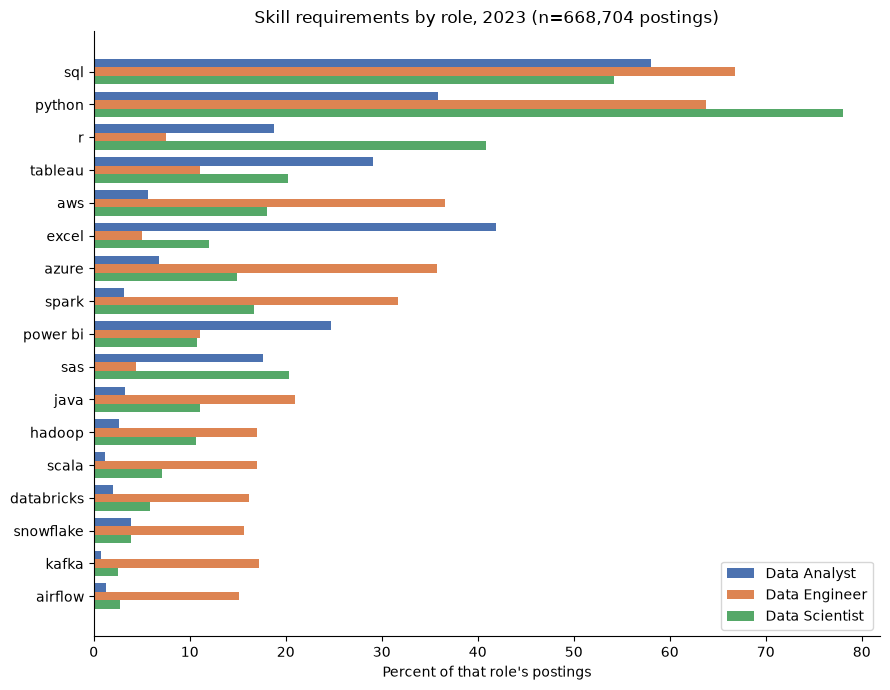

In [24]:
import matplotlib.pyplot as plt
import numpy as np

df = con.sql("""
SELECT skill,
       max(CASE WHEN role='Data Analyst'   THEN pct END) AS analyst,
       max(CASE WHEN role='Data Engineer'  THEN pct END) AS engineer,
       max(CASE WHEN role='Data Scientist' THEN pct END) AS scientist
FROM skill_pct
WHERE role IN ('Data Analyst','Data Engineer','Data Scientist')
  AND skill NOT IN ('go','flow')
GROUP BY skill
HAVING greatest(coalesce(max(CASE WHEN role='Data Analyst' THEN pct END),0),
                coalesce(max(CASE WHEN role='Data Engineer' THEN pct END),0),
                coalesce(max(CASE WHEN role='Data Scientist' THEN pct END),0)) >= 15
ORDER BY analyst + engineer + scientist
""").df().fillna(0)

y = np.arange(len(df)); h = 0.26
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(y + h, df.analyst,   h, label='Data Analyst',   color='#4C72B0')
ax.barh(y,     df.engineer,  h, label='Data Engineer',  color='#DD8452')
ax.barh(y - h, df.scientist, h, label='Data Scientist', color='#55A868')
ax.set_yticks(y); ax.set_yticklabels(df.skill)
ax.set_xlabel('Percent of that role\'s postings')
ax.set_title('Skill requirements by role, 2023 (n=668,704 postings)')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

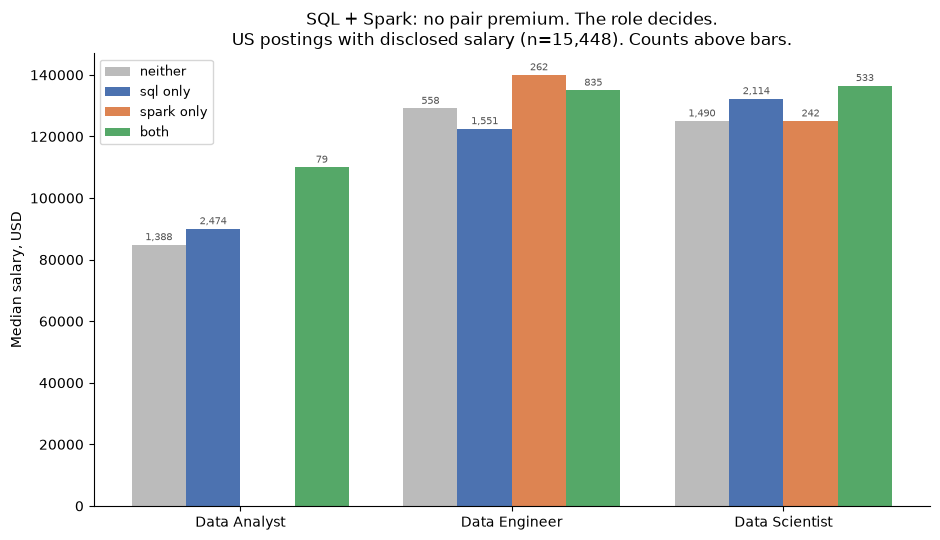

In [25]:
import matplotlib.pyplot as plt
import numpy as np

df = con.sql("""
SELECT role,
       CASE WHEN has_sql=1 AND has_spark=1 THEN 'both'
            WHEN has_spark=1 THEN 'spark only'
            WHEN has_sql=1 THEN 'sql only'
            ELSE 'neither' END AS grp,
       count(*) AS n, median(salary) AS med
FROM pair_base
WHERE role IN ('Data Analyst','Data Engineer','Data Scientist')
GROUP BY 1,2 HAVING count(*) >= 50
""").df()

order = ['neither','sql only','spark only','both']
roles = ['Data Analyst','Data Engineer','Data Scientist']
colors = ['#BBBBBB','#4C72B0','#DD8452','#55A868']

x = np.arange(len(roles)); w = 0.2
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, g in enumerate(order):
    vals, ns = [], []
    for r in roles:
        row = df[(df.role == r) & (df.grp == g)]
        vals.append(float(row.med.iloc[0]) if len(row) else np.nan)
        ns.append(int(row.n.iloc[0]) if len(row) else 0)
    pos = x + (i - 1.5) * w
    ax.bar(pos, vals, w, label=g, color=colors[i])
    for p, v, n in zip(pos, vals, ns):
        if not np.isnan(v):
            ax.text(p, v + 1500, f'{n:,}', ha='center', fontsize=7, color='#555')

ax.set_xticks(x); ax.set_xticklabels(roles)
ax.set_ylabel('Median salary, USD')
ax.set_title('SQL + Spark: no pair premium. The role decides.\nUS postings with disclosed salary (n=15,448). Counts above bars.')
ax.legend(title=None, fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

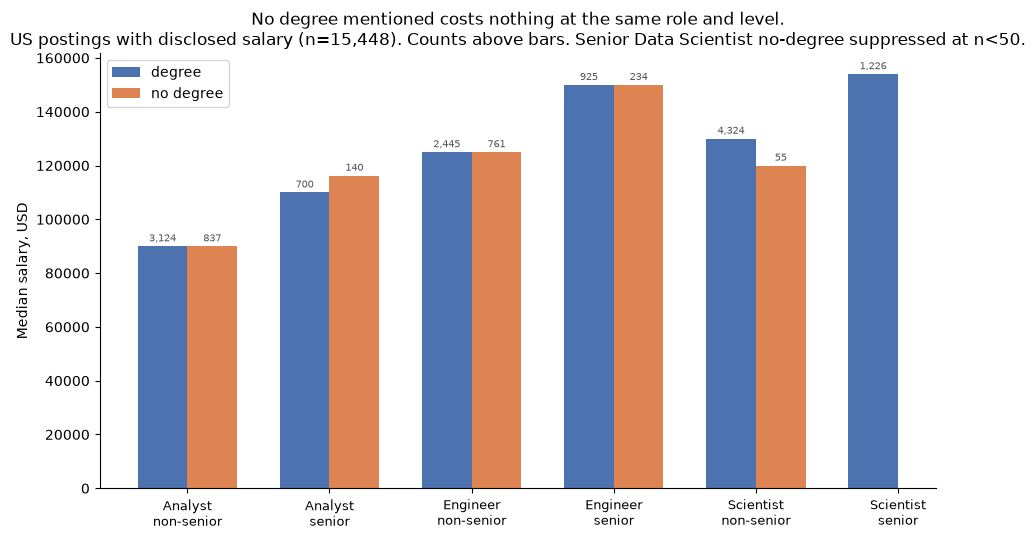

In [26]:
import matplotlib.pyplot as plt
import numpy as np

df = con.sql("""
SELECT regexp_replace(job_title_short,'^Senior ','') AS fam,
       CASE WHEN job_title_short LIKE 'Senior %' THEN 'senior' ELSE 'non-senior' END AS lvl,
       CASE WHEN job_no_degree_mention THEN 'no degree' ELSE 'degree' END AS deg,
       count(*) AS n, median(salary_year_avg) AS med
FROM us_salaried
WHERE regexp_replace(job_title_short,'^Senior ','')
      IN ('Data Analyst','Data Engineer','Data Scientist')
GROUP BY 1,2,3 HAVING count(*) >= 50
""").df()

cells = [(f, l) for f in ['Data Analyst','Data Engineer','Data Scientist']
                for l in ['non-senior','senior']]
labels = [f"{f.replace('Data ','')}\n{l}" for f, l in cells]

x = np.arange(len(cells)); w = 0.35
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, (deg, color) in enumerate([('degree','#4C72B0'), ('no degree','#DD8452')]):
    vals, ns = [], []
    for f, l in cells:
        row = df[(df.fam == f) & (df.lvl == l) & (df.deg == deg)]
        vals.append(float(row.med.iloc[0]) if len(row) else np.nan)
        ns.append(int(row.n.iloc[0]) if len(row) else 0)
    pos = x + (i - 0.5) * w
    ax.bar(pos, vals, w, label=deg, color=color)
    for p, v, n in zip(pos, vals, ns):
        if not np.isnan(v):
            ax.text(p, v + 1800, f'{n:,}', ha='center', fontsize=7, color='#555')

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Median salary, USD')
ax.set_title('No degree mentioned costs nothing at the same role and level.\n'
             'US postings with disclosed salary (n=15,448). Counts above bars. '
             'Senior Data Scientist no-degree suppressed at n<50.')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Decision

Three questions, three negative results. What follows from them.

**1. Target Data Engineer, not Data Scientist.**

The crossover from an analyst profile is cheapest there. SQL and Python already
carry over. AWS at 36.6 percent and Spark at 31.7 percent close most of the
remaining distance, and both are learnable without a credential. Data Scientist
requires R at 40.9 percent or a deep learning stack, and 98.7 percent of its
non-senior postings ask for a degree. That is an access wall, not a skill gap.

**2. Learn Spark and AWS. Stop collecting tools.**

Spark is worth 17,500 over SQL alone inside Data Engineer. AWS lifts the median
in all three roles. No pair tested beat its better half, so there is no combination
to assemble. One skill that pays in the target role beats four that do not.

**3. Do not buy a degree for the money.**

At the same role and level, postings that skip the degree requirement pay the
same. Three of four comparable cells match exactly. The degree buys entry to
Data Scientist roles and nothing measurable beyond that.

**4. Treat SQL as a prerequisite, not an achievement.**

54 to 67 percent of every role asks for it, and it carries no salary signal on
its own. It gets you considered. It does not get you paid.

### What would change these answers

Salary is disclosed on 2.8 percent of postings and skews to US pay transparency
jurisdictions, so every pay figure here describes the disclosing slice of the US
market. The data is calendar 2023, which predates most GenAI hiring. No control
for seniority beyond the title, company size, or industry. These are associations
in posting text, not causal effects, and posting language is not hiring behavior.